















































































### Importy

In [1]:
import pandas as pd
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from scipy.stats import mannwhitneyu

### Ścieżki do plików

In [2]:
ROOT_DIR = Path('..').resolve()
BLOCK_DIR = ROOT_DIR / 'outputs' / 'comparison_mutation_ERKKTR_ratio' / 'block_level_summary.csv'
GROUP_DIR = ROOT_DIR / 'outputs'  / 'comparison_mutation_ERKKTR_ratio' / 'group_level_summary.csv'


### Załadowanie plików

In [4]:
block_df = pd.read_csv(BLOCK_DIR)
group_df = pd.read_csv(GROUP_DIR)

### Testy statystyczne

In [5]:
# Przygotowanie danych dla WT
from statistics import mean


WT_mean = group_df[group_df['comparison_group']=='WT']['mean_relative_risk'][1]
print(WT_mean)
WT_samples = block_df[block_df['mutation']=='WT']['relative_risk']
# nazwy reszty mutantów
other_names = ['AKT1_E17K', 'PIK3CA_E545K', 'PIK3CA_H1047R', 'PTEN_del']

# Korekta Bonferroniego
alpha = 0.05
adjusted_alpha = alpha / len(other_names)


results = []
# pętla po mutantach
for mutant in other_names:

    mut_samples = block_df[block_df['mutation'] == mutant]['relative_risk']

    # test U Manna-Whitneya
    stat, p_value = mannwhitneyu(WT_samples, mut_samples, alternative='two-sided')

    RR_mean = mut_samples.mean()
    standard_error = mut_samples.sem()

    sig = p_value < adjusted_alpha

    results.append({
        'mutant': mutant,
        'statistic': stat,
        'RR_mean': RR_mean,
        'standard_error': standard_error,
        'p_value': p_value,
        'significant': sig
    })


results_df = pd.DataFrame(results)
import os
os.makedirs(Path('task_outputs'), exist_ok=True)
results_df.to_csv(Path('task_outputs') / 'WT_to_mutants_comparison.csv')


1.7423490027824606


### Wizualizacja

In [6]:
results_df

,mutant,statistic,RR_mean,standard_error,p_value,significant
0,AKT1_E17K,381.0,1.581421,0.071932,3.461467e-03,True
1,PIK3CA_E545K,353.0,1.707110,0.031885,1.835290e-01,False
2,PIK3CA_H1047R,0.0,3.200310,0.130643,3.063664e-09,True
3,PTEN_del,594.0,1.556633,0.021624,3.660584e-07,True


          mutant  statistic   RR_mean  standard_error       p_value  \
2  PIK3CA_H1047R        0.0  3.200310        0.130643  3.063664e-09   
1   PIK3CA_E545K      353.0  1.707110        0.031885  1.835290e-01   
0      AKT1_E17K      381.0  1.581421        0.071932  3.461467e-03   
3       PTEN_del      594.0  1.556633        0.021624  3.660584e-07   

   significant  
2         True  
1        False  
0         True  
3         True  
[0 1 2 3]


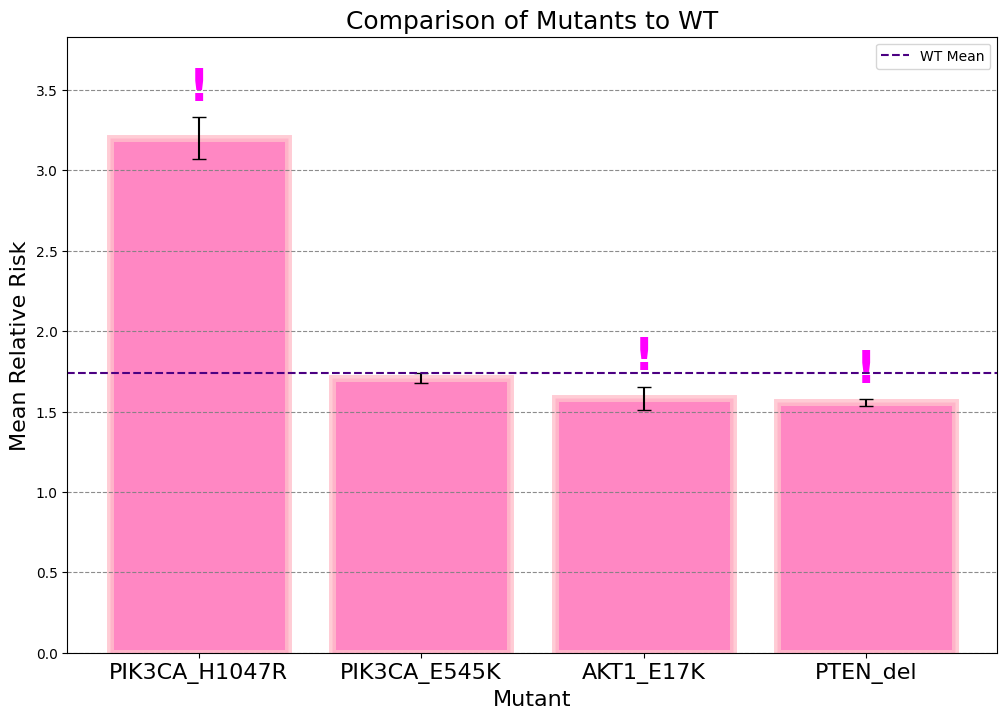

In [7]:
# Sortowanie mutantów według średniego RR
df_plot = results_df.sort_values('RR_mean', ascending=False)
print(df_plot)

plt.figure(figsize=(12, 8))

x_pos = np.arange(len(df_plot))
print(x_pos)

bar_plot = plt.bar(x_pos, df_plot['RR_mean'], yerr=df_plot['standard_error'],
         capsize=5, color='hotpink', edgecolor='pink', alpha=0.8, linewidth=5)

# Oznaczenie istotności 
for i, row in df_plot.iterrows():
    if row['significant']:
        plt.text(np.where(df_plot['mutant'] == row['mutant'])[0][0],
                  row['RR_mean'] + row['standard_error'] + 0.05, '!',
                  ha='center', va='bottom', fontsize=32, color = 'magenta', fontweight='bold')


plt.xticks(x_pos, df_plot['mutant'], fontsize=16)
plt.axhline(WT_mean, color='indigo', linestyle='--', label='WT Mean')
plt.xlabel('Mutant', fontsize=16)
plt.ylabel('Mean Relative Risk', fontsize=16)
plt.title('Comparison of Mutants to WT', fontsize=18)
plt.ylim(0, max(df_plot['RR_mean'] + df_plot['standard_error']) + 0.5)
plt.grid(color='gray', linestyle='--', axis='y', alpha=0.9)
plt.legend()
plt.savefig( Path('task_outputs') / 'WT_to_mutants_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretacja wyników

Celem przeprowadzonej analizy było zbadanie wpływu mutacji szlaku "PI3K-AKT" na koordynację sygnału ERK w komórkach MCF10A. Badanym wskaźnikiem był "RR_mean" - czyli średnie ryzyko względne, które określa jak bardzo skok aktywności sąsiada wpływa na prawdopodobieństwo własnej reakcji w ciągu ~15 minut. Wyniki dla mutantów porównano z typem dzikim - "WT", dla którego RR_mean wynosił ~1.7423, czyli wzrost szansy o 74.23%.

Dla mutantów: "PIK3CA_H1047R", "AKT1_E17K", "PTEN_del", zauważono statystycznie istotną zmianę. U "PIK3CA_E545K" nie zaobserwowano istotnych zmian

1) U "PIK3CA_H1047R" zaobserwowano najsilniejsze zmiany ze wszystkich grup. RR_mean wzrósł prawie dwukrotnie.
 Jego statystyki są następujące:
    - RR_mean = 3.200310 ;
    - standard_error = 0.130643 ; 
    - p_value < 0,001 ;

2) U "AKT1_E17K", "PTEN_del" zaobserwowano niewielki ale istotny spadek RR_mean w porównaniu do wariantu dzikiego.
Ich statystki są następujące
    - RR_mean 1.581421, 1.556633 ;    
    - standard_error = 0.071932, 0.021624 ; 
    - p_value < 0.01 ; 

3) U "PIK3CA_E545K" nie zaobserwowano istotnych zmian. Należy wnioskować że mutacja nie wpływa na szlak ERK.


Drastyczny wzrost RR_mean u mutanta "PIK3CA_H1047R" sugeruje, że mutacja ta silnie promuje produkcje i wydzielanie czynników sygnałowych odpowiedzialnych za rozprzestrzenianie się fal ERK. Równie prawdopodobnym wyjaśnieniem tego zjawiska jest to, że ta mutacja znacznie uwrażliwia komórkę na sygnały pochodzące od "sąsiadów".
Natomiast obniżenie RR_mean u "AKT1_E17K", "PTEN_del" można tłumaczyć zwiększoną stałą aktywnością bazową szlaku, co skutkuje na obniżoną podatność komórek na zewnętrzne sygnały.


